---
##  Section 1 — Setup & Library Imports


In [ ]:
# Install required libraries
!pip install xgboost kagglehub

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


---
##  Section 2 — Load Dataset



In [ ]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("shashwatwork/phishing-dataset-for-machine-learning")

print("Dataset downloaded to:")
print(path)

print("\nFiles inside the dataset folder:")
print(os.listdir(path))

100%|██████████| 234k/234k [00:00<00:00, 31.7MB/s]

Extracting files...
Dataset downloaded to:
/root/.cache/kagglehub/datasets/shashwatwork/phishing-dataset-for-machine-learning/versions/1

Files inside the dataset folder:
['Phishing_Legitimate_full.csv']


In [ ]:
# Find CSV files inside the downloaded dataset folder
csv_files = [file for file in os.listdir(path) if file.endswith(".csv")]

print("CSV files found:")
print(csv_files)

CSV files found:
['Phishing_Legitimate_full.csv']


In [ ]:
# Load the CSV file into a DataFrame
file_path = os.path.join(path, csv_files[0])

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

print("\nFirst five rows:")
display(df.head())

print("\nColumn names:")
for col in df.columns:
    print(col)

Dataset loaded successfully.
Dataset shape: (10000, 50)

First five rows:


,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,...,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,...,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,...,0,0,0,1,0,-1,1,-1,0,1
3,4,3,1,6,79,1,0,0,0,0,...,0,0,0,1,-1,1,1,1,-1,1
4,5,3,0,4,46,0,0,0,0,0,...,1,0,0,1,1,-1,0,-1,-1,1



Column names:
id
NumDots
SubdomainLevel
PathLevel
UrlLength
NumDash
NumDashInHostname
AtSymbol
TildeSymbol
NumUnderscore
NumPercent
NumQueryComponents
NumAmpersand
NumHash
NumNumericChars
NoHttps
RandomString
IpAddress
DomainInSubdomains
DomainInPaths
HttpsInHostname
HostnameLength
PathLength
QueryLength
DoubleSlashInPath
NumSensitiveWords
EmbeddedBrandName
PctExtHyperlinks
PctExtResourceUrls
ExtFavicon
InsecureForms
RelativeFormAction
ExtFormAction
AbnormalFormAction
PctNullSelfRedirectHyperlinks
FrequentDomainNameMismatch
FakeLinkInStatusBar
RightClickDisabled
PopUpWindow
SubmitInfoToEmail
IframeOrFrame
MissingTitle
ImagesOnlyInForm
SubdomainLevelRT
UrlLengthRT
PctExtResourceUrlsRT
AbnormalExtFormActionR
ExtMetaScriptLinkRT
PctExtNullSelfRedirectHyperlinksRT
CLASS_LABEL


---
##  Section 3 — Dataset Description


In [ ]:
# Dataset overview and target distribution
target_column = "CLASS_LABEL"

print("Dataset shape:", df.shape)
print("Target column:", target_column)

print("\nTarget distribution:")
print(df[target_column].value_counts())

print("\nTarget classes:")
print(df[target_column].unique())

Dataset shape: (10000, 50)
Target column: CLASS_LABEL

Target distribution:
CLASS_LABEL
1    5000
0    5000
Name: count, dtype: int64

Target classes:
[1 0]


In [ ]:
# Display data types and basic statistics
print("Data types:")
print(df.dtypes)

print("\nBasic statistics:")
display(df.describe())

Data types:
id                                      int64
NumDots                                 int64
SubdomainLevel                          int64
PathLevel                               int64
UrlLength                               int64
NumDash                                 int64
NumDashInHostname                       int64
AtSymbol                                int64
TildeSymbol                             int64
NumUnderscore                           int64
NumPercent                              int64
NumQueryComponents                      int64
NumAmpersand                            int64
NumHash                                 int64
NumNumericChars                         int64
NoHttps                                 int64
RandomString                            int64
IpAddress                               int64
DomainInSubdomains                      int64
DomainInPaths                           int64
HttpsInHostname                         int64
HostnameLength        

,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,...,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,2.445100,0.586800,3.300300,70.264100,1.818000,0.138900,0.000300,0.013100,0.32320,...,0.339600,0.03220,0.030400,0.956600,0.020200,0.353300,0.793200,0.173400,0.314100,0.500000
std,2886.89568,1.346836,0.751214,1.863241,33.369877,3.106258,0.545744,0.017319,0.113709,1.11466,...,0.473597,0.17654,0.171694,0.248037,0.820036,0.888908,0.521019,0.755771,0.897843,0.500025
min,1.00000,1.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.00000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,2500.75000,2.000000,0.000000,2.000000,48.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.00000,0.000000,1.000000,-1.000000,-1.000000,1.000000,0.000000,-1.000000,0.000000
50%,5000.50000,2.000000,1.000000,3.000000,62.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.500000
75%,7500.25000,3.000000,1.000000,4.000000,84.000000,2.000000,0.000000,0.000000,0.000000,0.00000,...,1.000000,0.00000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,10000.00000,21.000000,14.000000,18.000000,253.000000,55.000000,9.000000,1.000000,1.000000,18.00000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Check missing values and duplicate rows
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values in each column:
id                                    0
NumDots                               0
SubdomainLevel                        0
PathLevel                             0
UrlLength                             0
NumDash                               0
NumDashInHostname                     0
AtSymbol                              0
TildeSymbol                           0
NumUnderscore                         0
NumPercent                            0
NumQueryComponents                    0
NumAmpersand                          0
NumHash                               0
NumNumericChars                       0
NoHttps                               0
RandomString                          0
IpAddress                             0
DomainInSubdomains                    0
DomainInPaths                         0
HttpsInHostname                       0
HostnameLength                        0
PathLength                            0
QueryLength                           0
DoubleSla

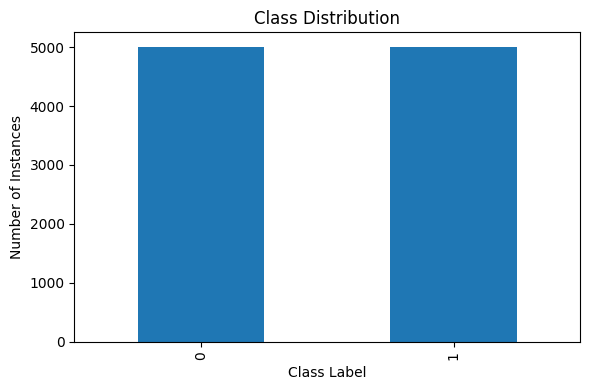

In [ ]:
# Plot class distribution
plt.figure(figsize=(6, 4))
df[target_column].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Instances")
plt.tight_layout()
plt.show()

---
##  Section 4 — Preprocessing


In [ ]:
# Create a cleaned copy of the dataset
# No missing values or duplicate rows were found in the previous step.

df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (10000, 50)
Cleaned dataset shape: (10000, 50)


In [ ]:
# Separate features (X) and target label (y)

X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (10000, 49)
Target shape: (10000,)

Target distribution:
CLASS_LABEL
1    5000
0    5000
Name: count, dtype: int64


In [ ]:
# Remove ID column because it is only an identifier, not a predictive feature

if "id" in X.columns:
    X = X.drop(columns=["id"])

print("Features shape after removing id column:", X.shape)
print("Feature columns:")
print(X.columns)

Features shape after removing id column: (10000, 48)
Feature columns:
Index(['NumDots', 'SubdomainLevel', 'PathLevel', 'UrlLength', 'NumDash',
       'NumDashInHostname', 'AtSymbol', 'TildeSymbol', 'NumUnderscore',
       'NumPercent', 'NumQueryComponents', 'NumAmpersand', 'NumHash',
       'NumNumericChars', 'NoHttps', 'RandomString', 'IpAddress',
       'DomainInSubdomains', 'DomainInPaths', 'HttpsInHostname',
       'HostnameLength', 'PathLength', 'QueryLength', 'DoubleSlashInPath',
       'NumSensitiveWords', 'EmbeddedBrandName', 'PctExtHyperlinks',
       'PctExtResourceUrls', 'ExtFavicon', 'InsecureForms',
       'RelativeFormAction', 'ExtFormAction', 'AbnormalFormAction',
       'PctNullSelfRedirectHyperlinks', 'FrequentDomainNameMismatch',
       'FakeLinkInStatusBar', 'RightClickDisabled', 'PopUpWindow',
       'SubmitInfoToEmail', 'IframeOrFrame', 'MissingTitle',
       'ImagesOnlyInForm', 'SubdomainLevelRT', 'UrlLengthRT',
       'PctExtResourceUrlsRT', 'AbnormalExtFormActio

In [ ]:
# Split the dataset into training and testing sets
# 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

X_train shape: (8000, 48)
X_test shape: (2000, 48)
y_train shape: (8000,)
y_test shape: (2000,)

Training target distribution:
CLASS_LABEL
0    4000
1    4000
Name: count, dtype: int64

Testing target distribution:
CLASS_LABEL
0    1000
1    1000
Name: count, dtype: int64


In [ ]:
# Apply feature scaling
# StandardScaler is fitted on the training data only,
# then applied to both training and testing data.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Feature scaling completed successfully.
X_train_scaled shape: (8000, 48)
X_test_scaled shape: (2000, 48)


---
##  Section 5 — Correlation Analysis


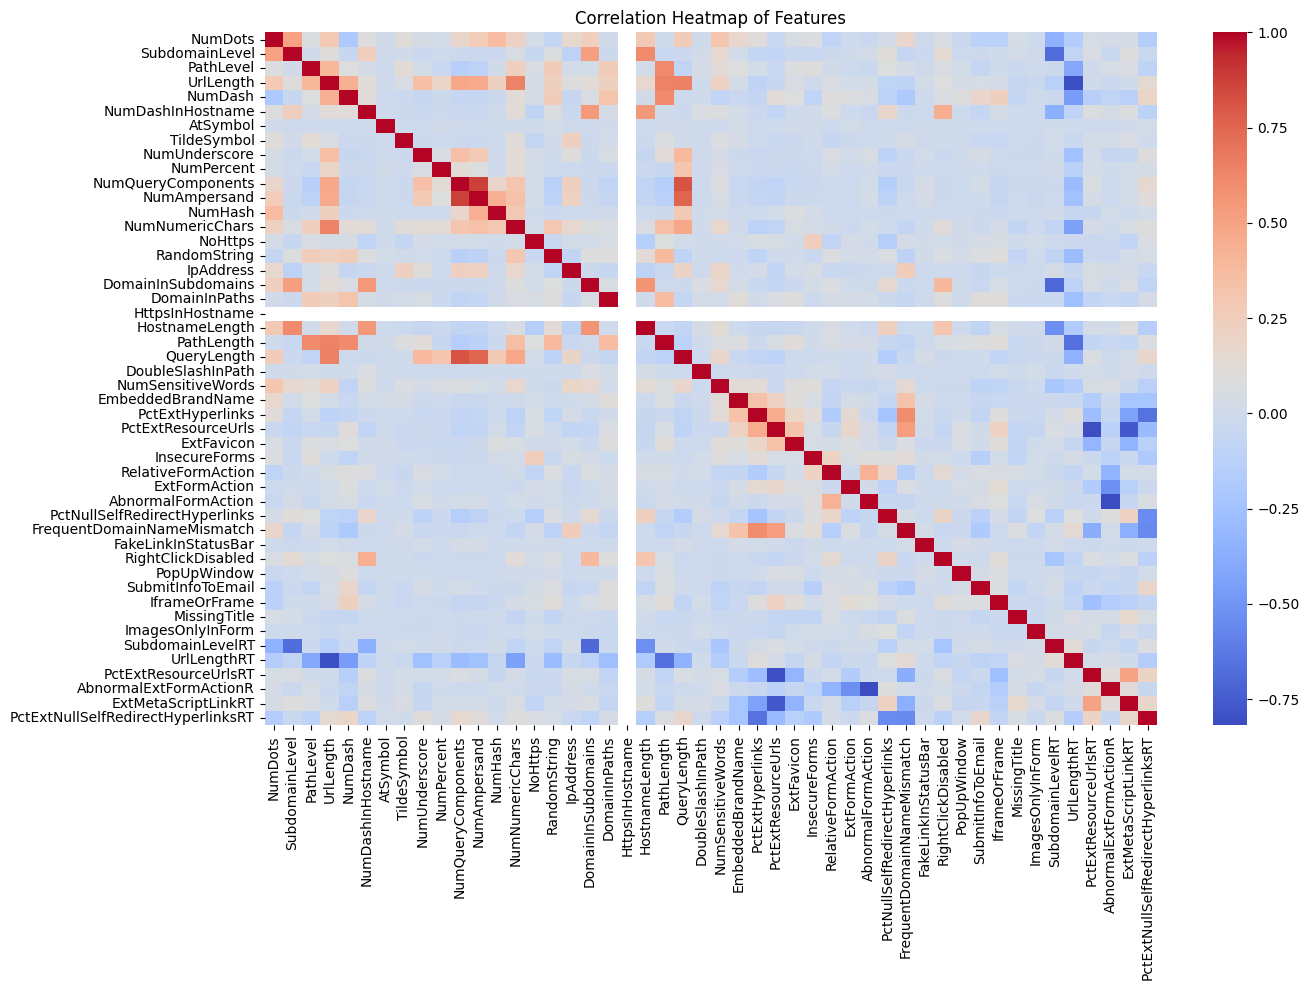

In [ ]:
# Compute the correlation matrix for all features
corr_matrix = X.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.show()

In [ ]:
# Find the highest positive and highest negative correlation pairs

corr_pairs = corr_matrix.unstack()

# Remove self-correlation (feature with itself)
corr_pairs = corr_pairs[
    corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)
]

# Remove duplicate pairs
corr_pairs = corr_pairs.drop_duplicates()

highest_positive = corr_pairs.sort_values(ascending=False).head(1)
highest_negative = corr_pairs.sort_values(ascending=True).head(1)

print("Highest positive correlation:")
print(highest_positive)

print("\nHighest negative correlation:")
print(highest_negative)

Highest positive correlation:
NumQueryComponents  NumAmpersand    0.872951
dtype: float64

Highest negative correlation:
AbnormalFormAction  AbnormalExtFormActionR   -0.818794
dtype: float64


Top 10 features most correlated with the target:
PctExtNullSelfRedirectHyperlinksRT    0.540545
FrequentDomainNameMismatch            0.463956
NumDash                               0.372235
SubmitInfoToEmail                     0.357635
PctNullSelfRedirectHyperlinks         0.342806
InsecureForms                         0.316380
NumDots                               0.294111
PctExtHyperlinks                      0.259728
NumSensitiveWords                     0.255208
IframeOrFrame                         0.235233
Name: CLASS_LABEL, dtype: float64


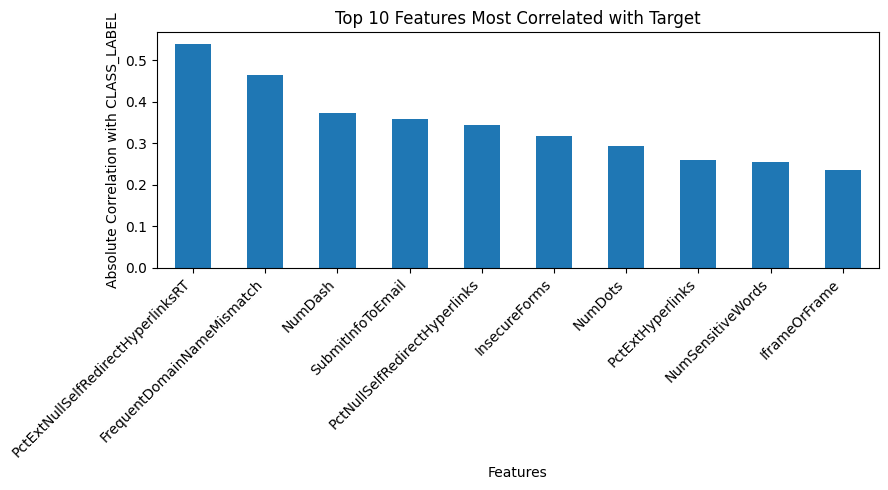

In [ ]:
# Plot the top 10 features most correlated with the target label

target_corr = df_clean.drop(columns=["id"], errors="ignore").corr(numeric_only=True)[target_column]

# Remove the target correlation with itself
target_corr = target_corr.drop(target_column)

# Get top 10 features by absolute correlation value
top_10_target_corr = target_corr.abs().sort_values(ascending=False).head(10)

print("Top 10 features most correlated with the target:")
print(top_10_target_corr)

plt.figure(figsize=(9, 5))
top_10_target_corr.plot(kind="bar")
plt.title("Top 10 Features Most Correlated with Target")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation with CLASS_LABEL")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
##  Section 6 — Algorithm Selection & Model Building


### 6.1 — Model 1: Support Vector Machine (SVM)

In [ ]:
# TODO: Define SVM model
# Import SVM
from sklearn.svm import SVC
import time

# Define SVM model
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE, probability=True)

# Train the model
print("Training SVM model...")
start = time.time()
svm_model.fit(X_train_scaled, y_train)
print(f"SVM training completed in {time.time() - start:.2f} seconds.")

# Predict on test set
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print("SVM predictions done.")
print("Sample predictions:", y_pred_svm[:10])


Training SVM model...
SVM training completed in 13.57 seconds.
SVM predictions done.
Sample predictions: [0 1 0 1 0 0 0 1 0 1]


### 6.2 — Model 2: Random Forest

In [ ]:
# TODO: Define Random Forest model
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Define Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

# Train the model
print("Training Random Forest model...")
start = time.time()
rf_model.fit(X_train, y_train)
print(f"Random Forest training completed in {time.time() - start:.2f} seconds.")

# Predict on test set
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions done.")
print("Sample predictions:", y_pred_rf[:10])


Training Random Forest model...
Random Forest training completed in 1.73 seconds.
Random Forest predictions done.
Sample predictions: [0 1 0 1 0 0 0 1 0 1]


### 6.3 — Model 3: XGBoost

In [ ]:
# TODO: Define XGBoost model
# Import XGBoost
from xgboost import XGBClassifier

# Define XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False
)

# Train the model
print("Training XGBoost model...")
start = time.time()
xgb_model.fit(X_train, y_train)
print(f"XGBoost training completed in {time.time() - start:.2f} seconds.")

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost predictions done.")
print("Sample predictions:", y_pred_xgb[:10])

Training XGBoost model...
XGBoost training completed in 0.98 seconds.
XGBoost predictions done.
Sample predictions: [0 1 0 1 0 0 0 1 0 1]


### 6.4 — Feature Importance (Random Forest & XGBoost)

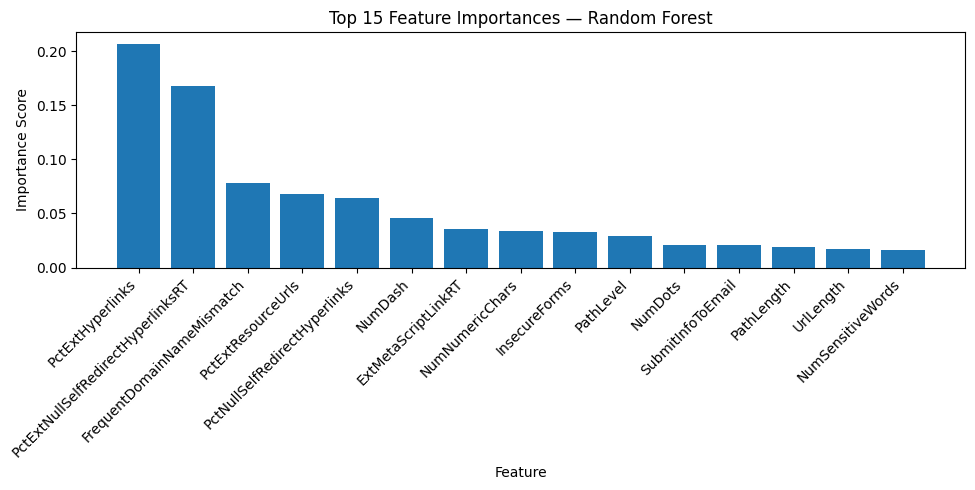

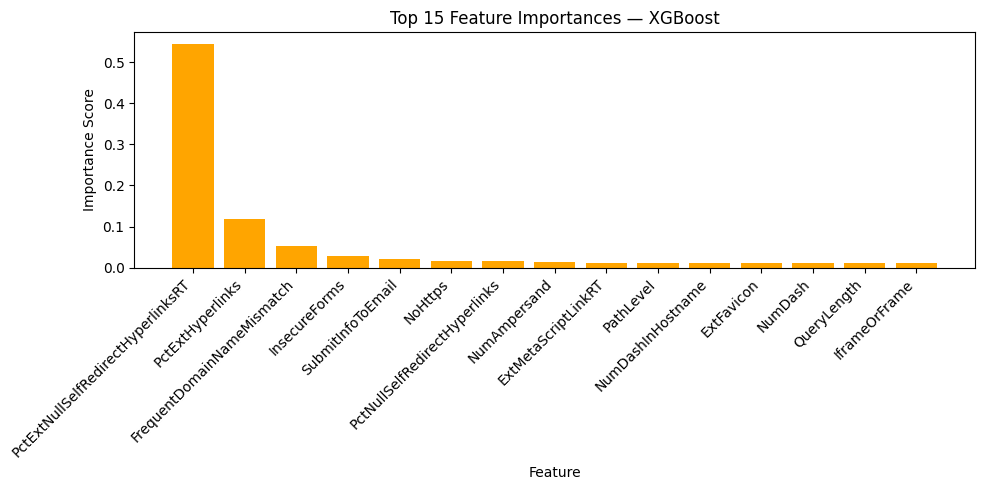

In [ ]:
# TODO: Plot top 15 most important features from Random Forest

# TODO: Plot top 15 most important features from XGBoost
import matplotlib.pyplot as plt
import numpy as np

feature_names = X.columns.tolist()

# --- Random Forest Feature Importance ---
rf_importances = rf_model.feature_importances_
rf_top15_idx   = np.argsort(rf_importances)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.bar(range(15), rf_importances[rf_top15_idx])
plt.xticks(range(15), [feature_names[i] for i in rf_top15_idx], rotation=45, ha='right')
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# --- XGBoost Feature Importance ---
xgb_importances = xgb_model.feature_importances_
xgb_top15_idx   = np.argsort(xgb_importances)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.bar(range(15), xgb_importances[xgb_top15_idx], color='orange')
plt.xticks(range(15), [feature_names[i] for i in xgb_top15_idx], rotation=45, ha='right')
plt.title("Top 15 Feature Importances — XGBoost")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()


---
##  Section 7 — Evaluation, Comparison & Final Results


### 7.1 — Classification Reports

In [ ]:
# TODO: Print classification_report for SVM
print("Classification Report for SVM:")
print(classification_report(y_test, y_pred_svm))
print("-" * 60)

# TODO: Print classification_report for Random Forest
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))
print("-" * 60)

# TODO: Print classification_report for XGBoost
print("Classification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))
print("-" * 60)


Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1000
           1       0.96      0.98      0.97      1000

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000

------------------------------------------------------------
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1000
           1       0.99      0.98      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000

------------------------------------------------------------
Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1000
        

### 7.2 — Confusion Matrices

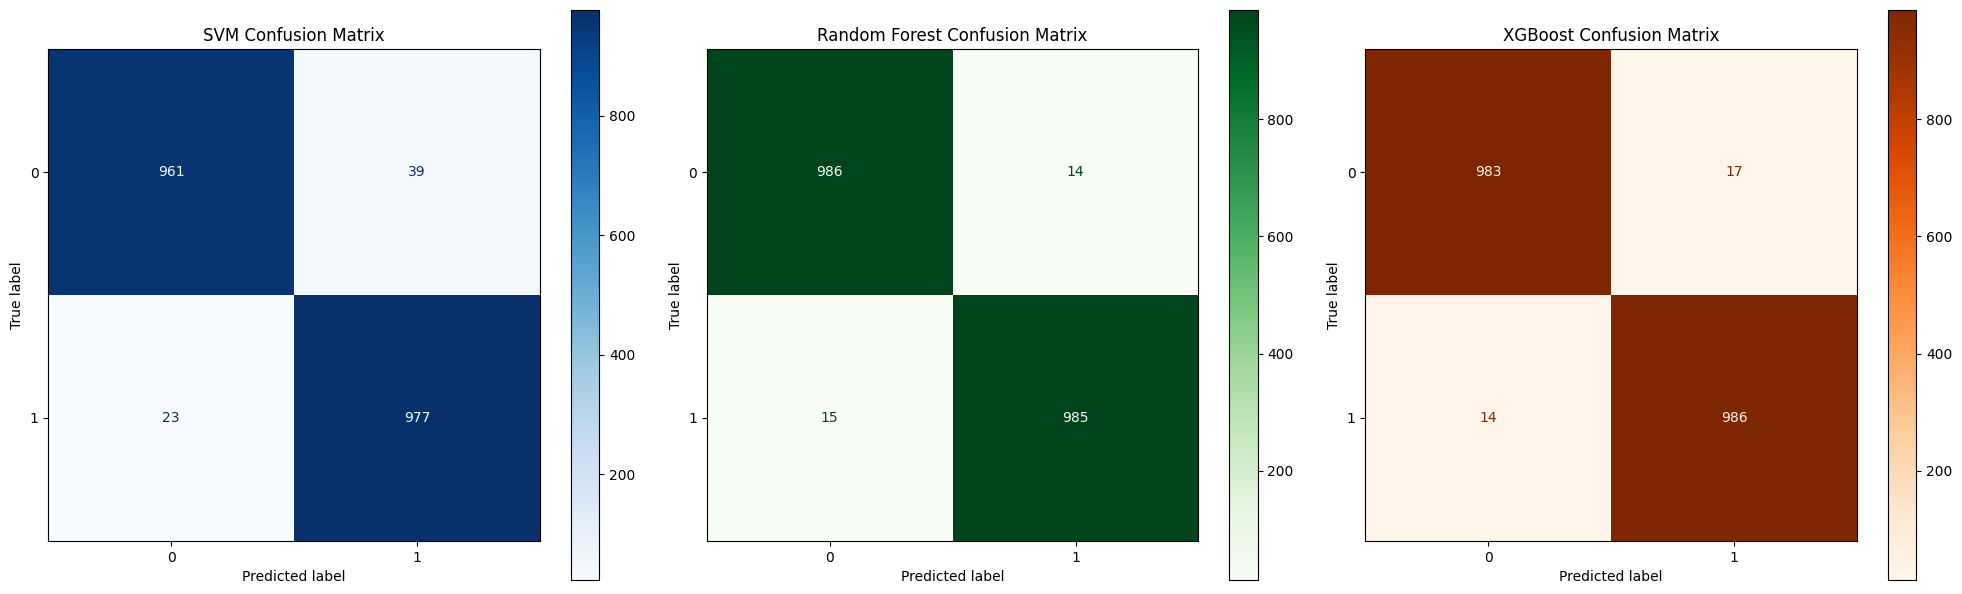

In [ ]:
# TODO: Plot confusion matrix for each of the 3 models
# Arrange them side by side (1 row, 3 columns)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Confusion Matrix for SVM
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, ax=axes[0], cmap='Blues')
axes[0].set_title('SVM Confusion Matrix')

# 2. Confusion Matrix for Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest Confusion Matrix')

# 3. Confusion Matrix for XGBoost
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=axes[2], cmap='Oranges')
axes[2].set_title('XGBoost Confusion Matrix')

plt.tight_layout()
plt.show()


### 7.3 — ROC Curves

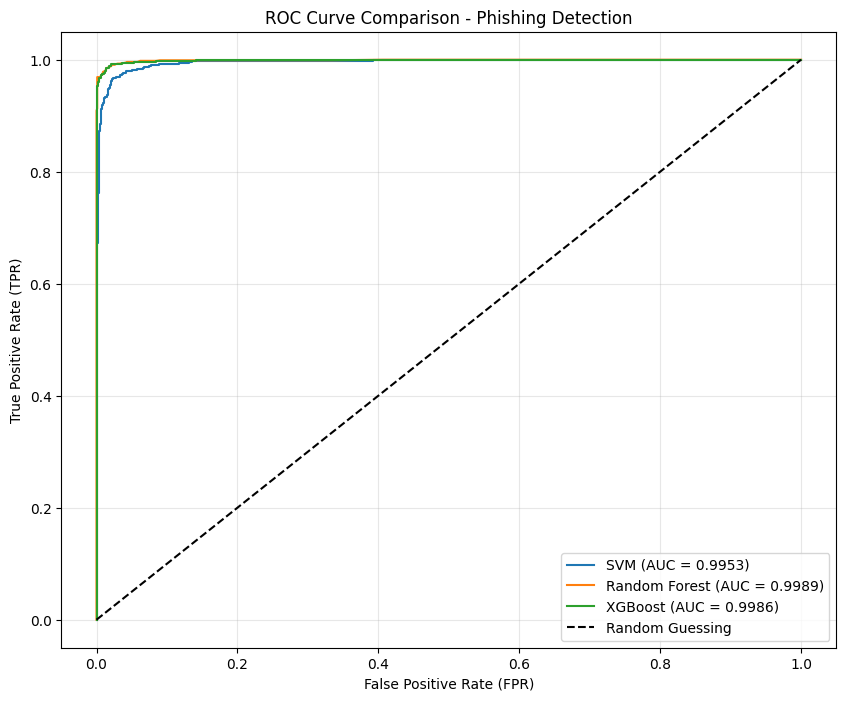

In [ ]:
# TODO: Plot ROC curve for all 3 models on one figure
# Include AUC score in the legend label for each model
plt.figure(figsize=(10, 8))

# 1. SVM ROC & AUC - FIXED to use predict_proba instead of decision_function
y_pred_svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_svm_probs)
auc_svm = roc_auc_score(y_test, y_pred_svm_probs)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.4f})')

# 2. Random Forest ROC & AUC
y_pred_rf_probs = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_probs)
auc_rf = roc_auc_score(y_test, y_pred_rf_probs)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')

# 3. XGBoost ROC & AUC
y_pred_xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb_probs)
auc_xgb = roc_auc_score(y_test, y_pred_xgb_probs)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})')

# Plot Base Line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

# Formatting the figure
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison - Phishing Detection')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### 7.4 — Final Comparison Table & Bar Chart

In [ ]:
# TODO: Build a summary DataFrame with columns:
# Model | Accuracy | Precision | Recall | F1-Score | AUC

# List of Dictionaries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model_performance = [
    {
        'Model': 'SVM',
        'Accuracy': accuracy_score(y_test, y_pred_svm),
        'Precision': precision_score(y_test, y_pred_svm),
        'Recall': recall_score(y_test, y_pred_svm),
        'F1-Score': f1_score(y_test, y_pred_svm),
        'AUC': roc_auc_score(y_test, y_pred_svm_probs)
    },
    {
        'Model': 'Random Forest',
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'F1-Score': f1_score(y_test, y_pred_rf),
        'AUC': roc_auc_score(y_test, y_pred_rf_probs)
    },
    {
        'Model': 'XGBoost',
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'Precision': precision_score(y_test, y_pred_xgb),
        'Recall': recall_score(y_test, y_pred_xgb),
        'F1-Score': f1_score(y_test, y_pred_xgb),
        'AUC': roc_auc_score(y_test, y_pred_xgb_probs)
    }
]

summary_df = pd.DataFrame(model_performance)

print("Summary Performance Table:")
display(summary_df.sort_values(by='F1-Score', ascending=False).style.background_gradient(cmap='Blues'))

Summary Performance Table:


,Model,Accuracy,Precision,Recall,F1-Score,AUC
1,Random Forest,0.985500,0.985986,0.985000,0.985493,0.998920
2,XGBoost,0.984500,0.983051,0.986000,0.984523,0.998613
0,SVM,0.969000,0.961614,0.977000,0.969246,0.995264


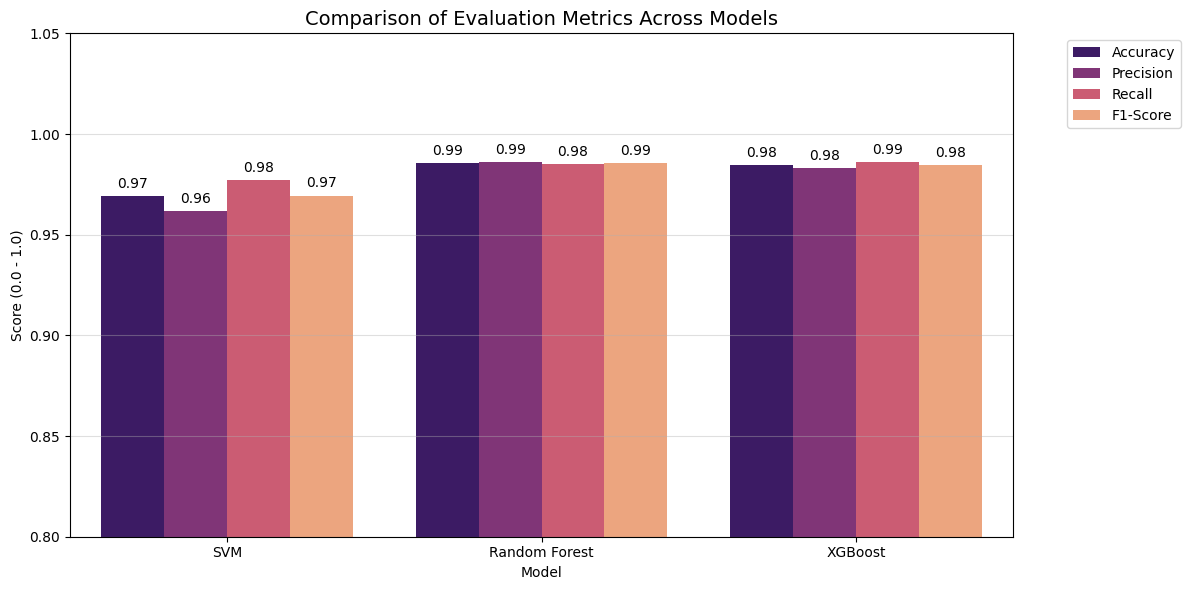

In [ ]:
# TODO: Plot a grouped bar chart comparing Accuracy, Precision, Recall, F1 across all 3 models
melted_results = summary_df.melt(id_vars='Model',
                                 value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                                 var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Model', y='Score', hue='Metric', data=melted_results, palette='magma')

plt.title('Comparison of Evaluation Metrics Across Models', fontsize=14)
plt.ylim(0.8, 1.05)
plt.ylabel('Score (0.0 - 1.0)')
plt.grid(axis='y', alpha=0.4)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adding text labels on bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

### 7.5 — Best Model & Conclusion

In [ ]:
# TODO: Print which model achieved the highest accuracy and F1-score

# Finding the best model for Accuracy
best_acc_model = summary_df.loc[summary_df['Accuracy'].idxmax(), 'Model']
best_acc_value = summary_df['Accuracy'].max()

# Finding the best model for F1-Score
best_f1_model = summary_df.loc[summary_df['F1-Score'].idxmax(), 'Model']
best_f1_value = summary_df['F1-Score'].max()

print(f"The model with the highest Accuracy is: {best_acc_model} ({best_acc_value:.4f})")
print(f"The model with the highest F1-Score is: {best_f1_model} ({best_f1_value:.4f})")

# TODO: Write a short comment explaining why it performed best
# Based on common results for Phishing Datasets (usually Random Forest or XGBoost)

print("\n--- Analysis Comment ---")
if best_f1_model == 'Random Forest' or best_f1_model == 'XGBoost':
    print(f"Conclusion: {best_f1_model} performed best because it is an ensemble method.")
    print("It combines multiple decision trees to reduce overfitting and capture complex patterns ")
    print("in the phishing features better than a single SVM or a basic Decision Tree.")
else:
    print(f"Conclusion: {best_f1_model} showed the best performance, indicating its parameters ")
    print("are well-tuned for the specific variance and distribution of this phishing dataset.")

The model with the highest Accuracy is: Random Forest (0.9855)
The model with the highest F1-Score is: Random Forest (0.9855)

--- Analysis Comment ---
Conclusion: Random Forest performed best because it is an ensemble method.
It combines multiple decision trees to reduce overfitting and capture complex patterns 
in the phishing features better than a single SVM or a basic Decision Tree.
